Aprendizaje Automatico 1

Trabajo Práctico Nº 2

Integrantes: Quinteros, Lasarte, Lazarte

Columnas:


*   Date (Temporal): Fecha del registro (formato año-mes-día).
*   Location (Catagórica): Ciudad meteorológica donde se tomó la medición.
*   MinTemp (Numérica): Temperatura mínima del día (°C).
*   MaxTemp (Numérica): Temperatura máxima del día (°C).
*   Rainfall (Numérica): Cantidad de lluvia caída en el día (mm).
*   Evaporatio (Numérica): Cantidad de agua evaporada (mm).
*   Sunshine (Numérica): Horas de sol durante el día.
*   WindGustDir (Catagórica): Dirección de la ráfaga de viento más fuerte.
*   WindGustSpeed (Numérica): Velocidad máxima de ráfaga de viento (km/h).
*   WindDir9am (Catagórica): Dirección del viento a las 9 am.
*   WindDir3pm (Catagórica): Dirección del viento a las 3 pm.
*   WindSpeed9am (Numérica): Velocidad del viento a las 9 am.
*   WindSpeed3pm (Numérica): Velocidad del viento a las 3 pm.
*   Humidity9am (Numérica): Humedad relativa (%) a las 9 am.
*   Humidity3pm (Numérica): Humedad relativa (%) a las 3 pm.
*   Pressure9am (Numérica): Presión atmosférica (hPa) a las 9 am.
*   Pressure3pm (Numérica): Presión atmosférica (hPa) a las 3 pm.
*   Cloud9am (Numérica): Nubosidad a las 9 am (escala de 0 a 8, donde 8 es cielo totalmente cubierto).
*   Cloud3pm (Numérica): Nubosidad a las 3 pm.
*   Temp9am (Numérica): Temperatura medida a las 9 am.
*   Temp3pm (Numérica): Temperatura medida a las 3 pm.
*   RainToday (Catagórica): Indica si llovió ese día (Yes/No).
*   RainTomorrow (Catagórica): Indica si va a llover al día siguiente.
*   RainfallTomorrow (Numérica): Cantidad de lluvia del día siguiente (mm).



In [218]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, classification_report, confusion_matrix
)

In [186]:
clima = pd.read_csv('weatherAUS_2026C1.csv')

In [187]:
clima.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [188]:
clima.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       130351 non-nu

In [ ]:
clima.describe()

In [189]:
clima = clima.drop('Unnamed: 0', axis = 1) # Se borra porque es simplemente un índice (contador de filas). No aporta información meteorológica.

In [190]:
print("Cantidad de valores NaN:")
print(f"\n{clima.isnull().sum()}")

Cantidad de valores NaN:

Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64


In [191]:
#porcentaje de valores nulos por variable
print("\nPorcentaje de valores NaN:")
print(f"\n{(clima.isnull().sum() / len(clima)) * 100}")


Porcentaje de valores NaN:

Date                 0.000000
Location             0.000000
MinTemp              1.020549
MaxTemp              0.861690
Rainfall             2.241906
Evaporation         43.155998
Sunshine            47.998790
WindGustDir          7.094325
WindGustSpeed        7.051000
WindDir9am           7.263500
WindDir3pm           2.906225
WindSpeed9am         1.215168
WindSpeed3pm         2.105053
Humidity9am          1.824471
Humidity3pm          3.098094
Pressure9am         10.357467
Pressure3pm         10.332022
Cloud9am            38.421863
Cloud3pm            40.805436
Temp9am              1.214480
Temp3pm              2.480538
RainToday            2.241906
RainTomorrow         2.241218
RainfallTomorrow     2.241218
dtype: float64


In [192]:
#limpieza pre-split: sacamos columnas leakage, filas sin target y encodeamos
clima = clima.drop(columns=['RainfallTomorrow'])
clima = clima.dropna(subset=['RainTomorrow'])
clima['RainTomorrow'] = clima['RainTomorrow'].map({'No': 0, 'Yes': 1}).astype(int)

In [193]:
#extraemos month de Date y lo encodeamos cíclico para el modelo
clima['Date'] = pd.to_datetime(clima['Date'])
clima['Month'] = clima['Date'].dt.month
clima['Month_sin'] = np.sin(2 * np.pi * clima['Date'].dt.month / 12)
clima['Month_cos'] = np.cos(2 * np.pi * clima['Date'].dt.month / 12)
clima = clima.drop(columns=['Date'])

#Separamos features y targets
X = clima.drop(columns=['RainTomorrow'])
y = clima['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(113722, 24) (28431, 24)


Hacemos los boxplots sobre X_train para describir lo que el modelo va a ver. Si lo hiciesemos sobre todo el dataset, estariamos mirando informacion del test al hacer el analisis, lo que es una forma de leakage, ya que esto nos haria tomar decisiones sobre el preprocesamiento o el modelo basado en los datos del test.

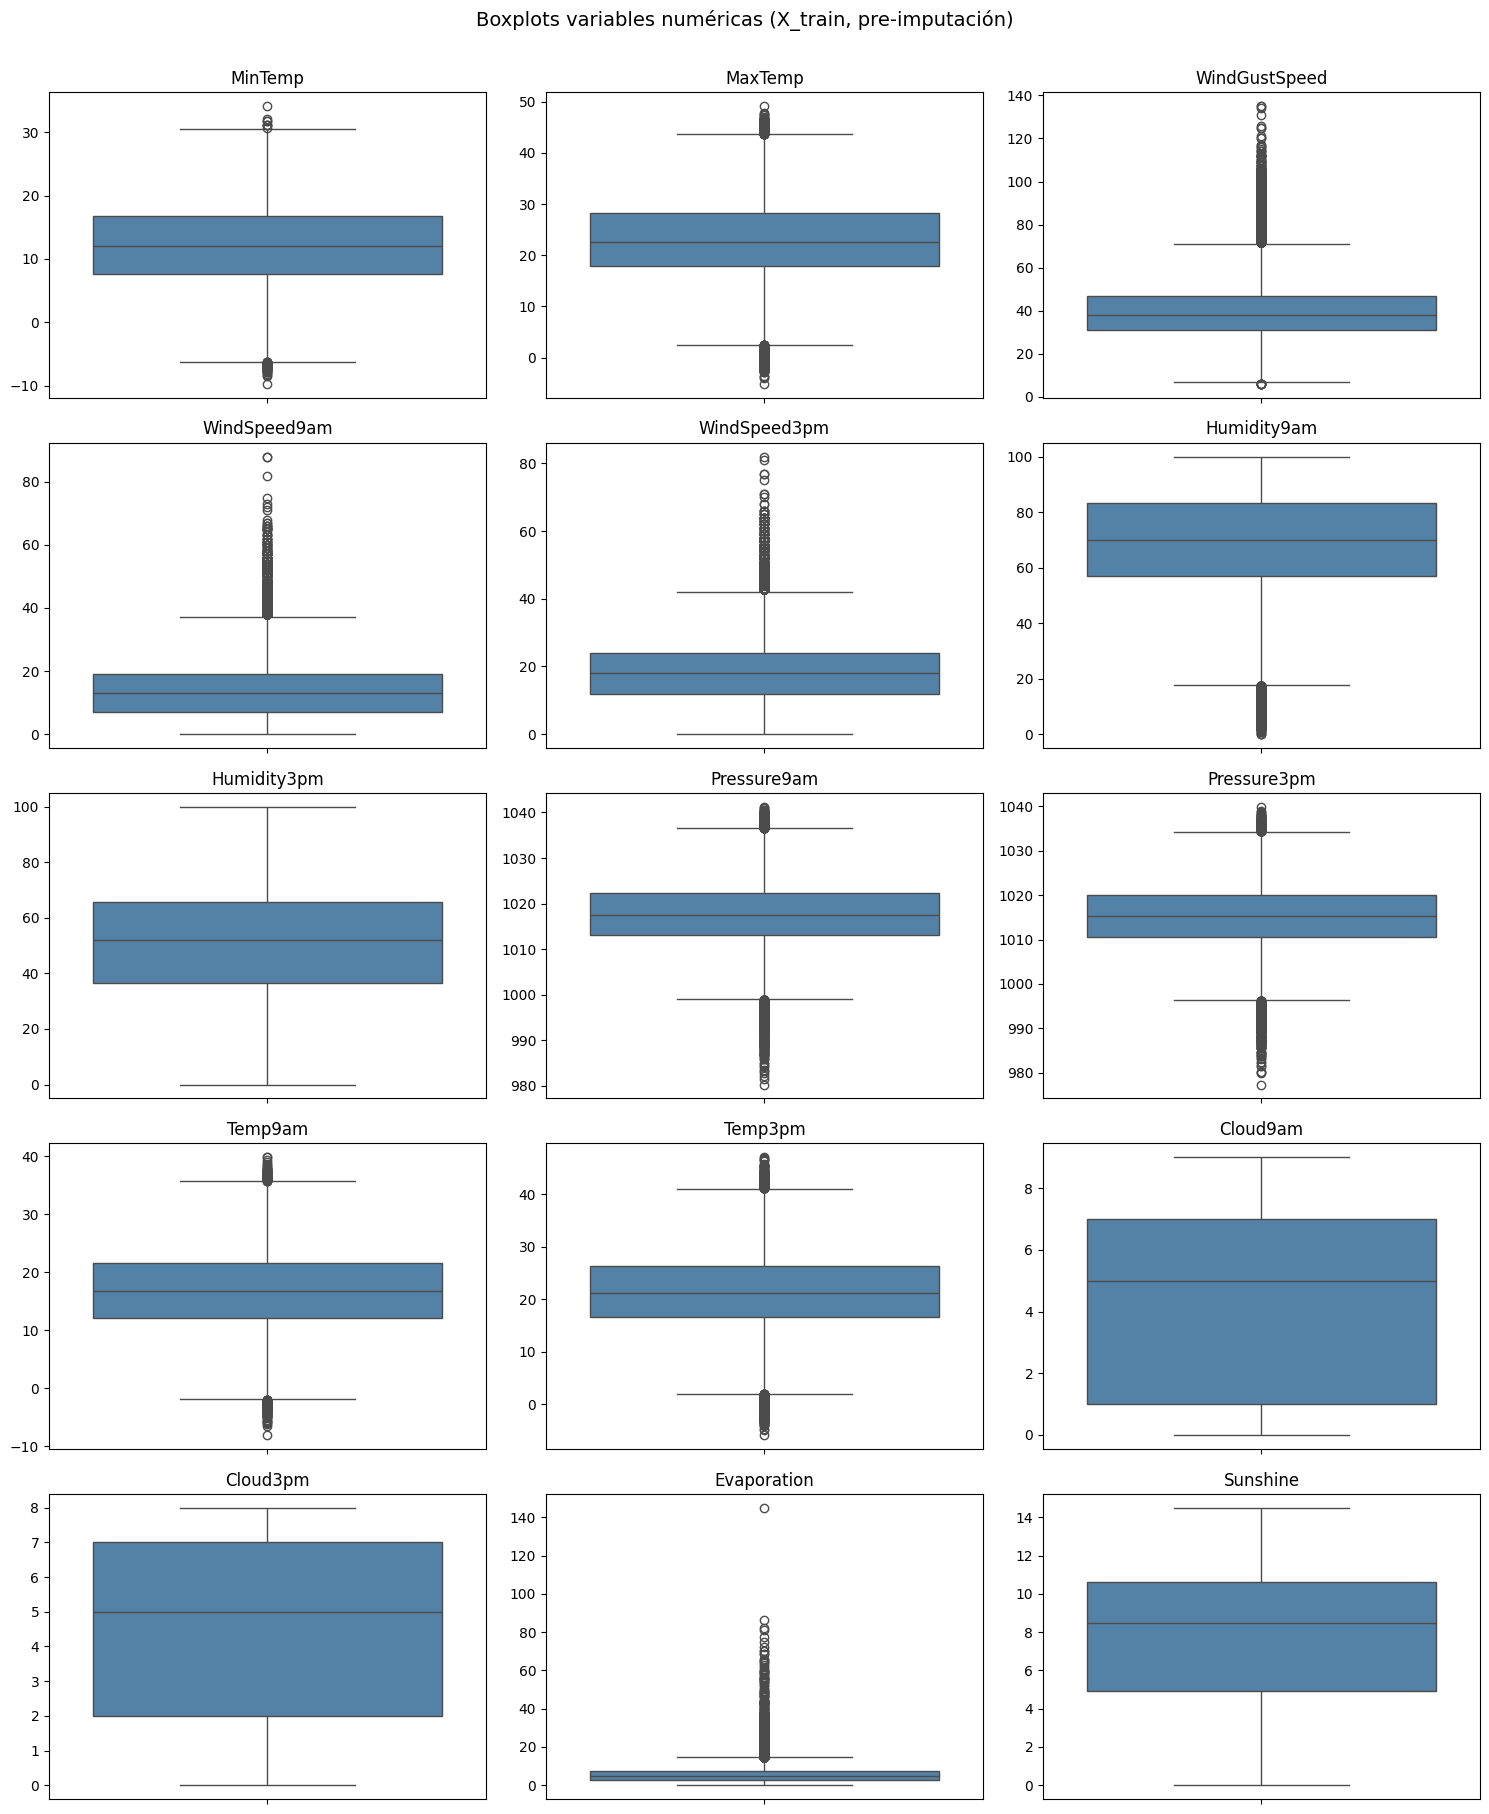

In [194]:
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
for i, c in enumerate(vars_num):
    ax = axes[i // 3, i % 3]
    sns.boxplot(y=X_train[c], ax=ax, color='steelblue')   # ← X_train, no X1_train
    ax.set_title(c)
    ax.set_ylabel('')
plt.suptitle('Boxplots variables numéricas (X_train, pre-imputación)', fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


In [195]:
conteo = y_train.value_counts()
porcentaje = y_train.value_counts(normalize=True) * 100

print("Conteo:")
print(conteo)

print("\nPorcentaje:")
print(porcentaje)

Conteo:
RainTomorrow
0    88224
1    25498
Name: count, dtype: int64

Porcentaje:
RainTomorrow
0    77.578657
1    22.421343
Name: proportion, dtype: float64


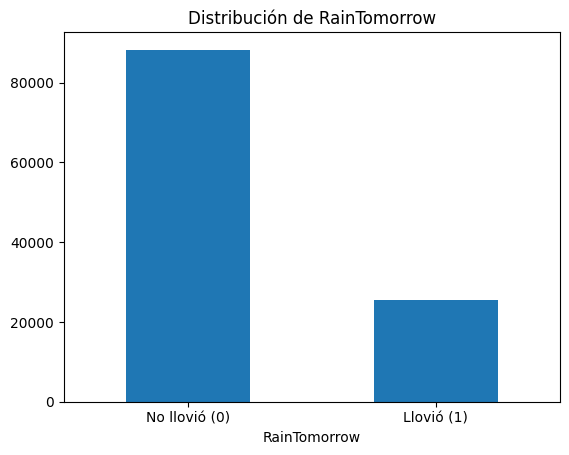

In [196]:
y_train.value_counts().plot(kind='bar')
plt.title('Distribución de RainTomorrow')
plt.xticks([0, 1], ['No llovió (0)', 'Llovió (1)'], rotation=0)
plt.xlabel('RainTomorrow')
plt.show()

El Dataset está claramente desbalanceado, por lo que se deberá solucionar este problema más adelante

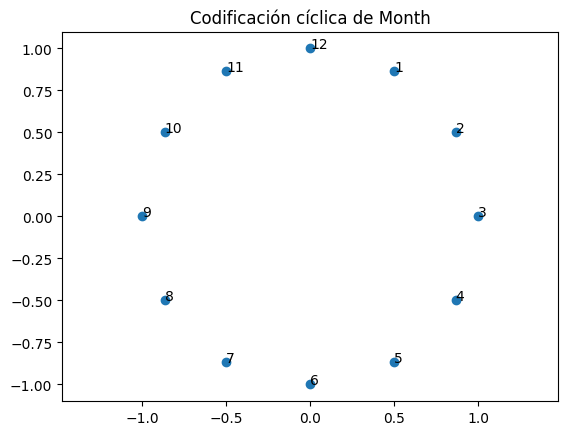

In [197]:
months_test = np.arange(1, 13)
plt.scatter(np.sin(2*np.pi*months_test/12), np.cos(2*np.pi*months_test/12))
for m in months_test:
    plt.annotate(str(m), (np.sin(2*np.pi*m/12), np.cos(2*np.pi*m/12)))
plt.title('Codificación cíclica de Month')
plt.axis('equal')
plt.show()


Tratamiento de NaNs:



*   Rainfall: Reemplazamos NaN por 0. Asumimos que NaN significa "no se registró"
*   'RainToday': Se reemplazó NaN por 'No' (moda), codificamos a 1/0
*   RainTomorrow (target): eliminamos filas con NaN. No se puede entrenar contra un objetivo desconocido
*   RainfallTomorrow: Se elimina la columna ya que no se usa en el modelo ya que es el leakage en si
* Antes de imputar variables numericas, agregamos flags binarios para las columnas con alta proporcion de NaN. Porque una vez imputados los NaNs se pierde la distincion. Por lo tanto permite que el modelo preserve la informacion de que valores fueron imputados
- Categoricas:
*   WindGustDir, WindDir9am, WindDir3pm: Imputamos en cascada de 3 niveles porque hay algunas combinaciones que no tienen datos suficientes en train. Imputamos de mas especifico a menos (location, month) -> (location) -> (moda global)
 Los estadísticos se calculan solo con X_train para evitar leakage, y se aplican a X_test.

- Numericas: 
*   MinTemp, MaxTemp, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Temp9am, Temp3pm, Cloud9am, Cloud3pm: Reemplazamos con la misma cascada pero con la mediana debido a outliers
* Evaporation y Sunshine: tienen un gran porcentaje de NaN (>40%) por lo tanto probamos 2 estrategias para luego comparar:
    - clima 1: conservamos variables e imputamos por cascada + flag
    - clima 2: las eliminamos junto con sus flags

En el item 2 entrenamos la regresion logistica sobre los datasets para ver cual estrategia generaliza mejor

* Location y month: los usamos solo como agrupadores para imputar.
    - Motivos de 'Location': no hacer one-hot encoding sobre las 49 ciudades. Algunas aparecen pocas veces.
    - Motivos 'month: ya creamos dos features nuevas que codifican la posicion del mes ciclicamente



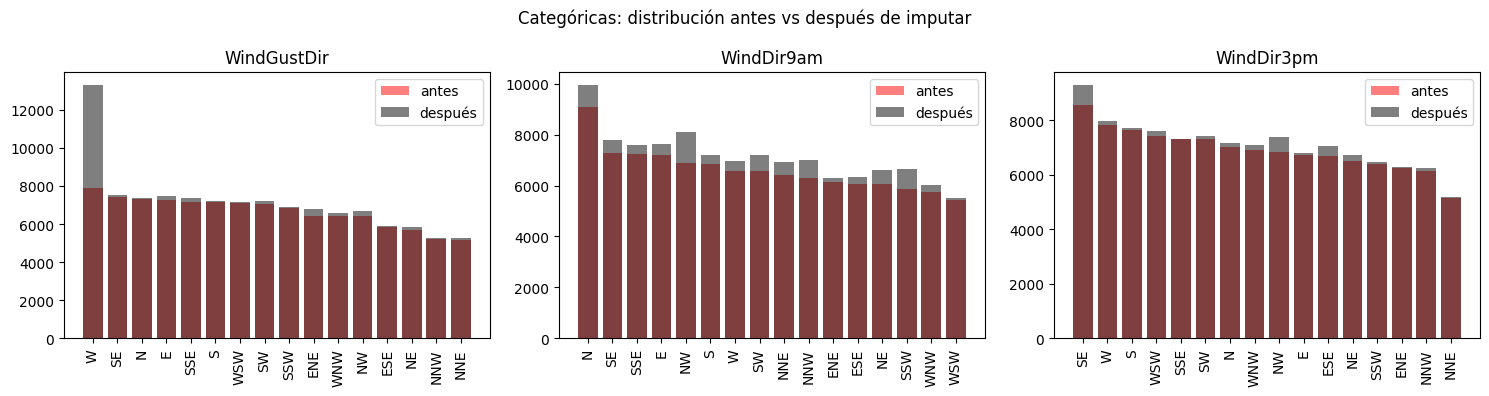

clima1: (113722, 77) (28431, 77) | NaN: 0 0
clima2: (113722, 73) (28431, 73) | NaN: 0 0


In [199]:
# Imputación con leakage fix
# Cascada (Location, Month) → Location → global, fit solo en X_train

X1_train = X_train.copy()
X1_test = X_test.copy()

#1 Imputaciones constantes (no requieren stats del dataset)
for X in [X1_train, X1_test]:
    X['Rainfall'] = X['Rainfall'].fillna(0)        #Como no esta registrado (NaN), asumimos 0 mm
    X['RainToday'] = X['RainToday'].fillna('No')   #lo  mismo para rain today

#2 creamos Flags _missing antes de imputar (preservan info de "fue NaN")
cols_flag = ['Humidity9am','Humidity3pm','Pressure9am','Pressure3pm',
             'Temp9am','Temp3pm','Cloud9am','Cloud3pm','Evaporation','Sunshine']
for c in cols_flag:
    X1_train[c + '_missing'] = X1_train[c].isna().astype(int)
    X1_test[c + '_missing'] = X1_test[c].isna().astype(int)

#3 funcion auxiliar: cascada (Location, Month) → Location → global
def imputar_cascada(X, col, stat_loc_month, stat_loc, stat_global):
    keys = pd.MultiIndex.from_arrays([X['Location'].values, X['Month'].values])
    vals = stat_loc_month.reindex(keys).values
    X[col] = X[col].fillna(pd.Series(vals, index=X.index))
    X[col] = X[col].fillna(X['Location'].map(stat_loc))
    X[col] = X[col].fillna(stat_global)

#4 imputamos Categóricas: moda con cascada (stats calculadas en X1_train)
for c in ['WindGustDir','WindDir9am','WindDir3pm']:
    moda_global = X1_train[c].mode(dropna=True).iloc[0]
    modas_loc = X1_train.groupby('Location')[c].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else moda_global)
    modas_loc_month = X1_train.groupby(['Location','Month'])[c].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    for X in [X1_train, X1_test]:
        imputar_cascada(X, c, modas_loc_month, modas_loc, moda_global)

#5 Numéricas: mediana con cascada (stats calculadas en X1_train)
cols_num = ['MinTemp','MaxTemp','WindGustSpeed','WindSpeed9am','WindSpeed3pm',
            'Humidity9am','Humidity3pm','Pressure9am','Pressure3pm',
            'Temp9am','Temp3pm','Cloud9am','Cloud3pm','Evaporation','Sunshine']
for c in cols_num:
    med_global = X1_train[c].median()
    meds_loc = X1_train.groupby('Location')[c].median()
    meds_loc_month = X1_train.groupby(['Location','Month'])[c].median()
    for X in [X1_train, X1_test]:
        imputar_cascada(X, c, meds_loc_month, meds_loc, med_global)

#6 Encodeamos RainToday para el modelo lineal Yes/No → 1/0
for X in [X1_train, X1_test]:
    X['RainToday'] = X['RainToday'].map({'Yes': 1, 'No': 0}).astype(int)

#7 Dropeamos Location y Month (porque ya cumplieron su rol como agrupadores). 
#Las variables metereologicas ya capturan el efecto local, y month ya lo tenemos como feature ciclica
#solo las utilizamos para agrupar y no para el modelo
X1_train = X1_train.drop(columns=['Location','Month'])
X1_test  = X1_test.drop(columns=['Location','Month'])

#8 Variante clima2: realizamos la misma imputación pero sin Evap/Sun ni sus flags
X2_train = X1_train.drop(columns=['Evaporation','Sunshine','Evaporation_missing','Sunshine_missing'])
X2_test  = X1_test.drop(columns=['Evaporation','Sunshine','Evaporation_missing','Sunshine_missing'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, c in enumerate(['WindGustDir', 'WindDir9am', 'WindDir3pm']):
    antes = X_train[c].value_counts(dropna=True)
    despues = X1_train[c].value_counts(dropna=True)

    ax = axes[i]
    x = range(len(antes))
    ax.bar(x, antes.values, alpha=0.5, color='red', label='antes')
    ax.bar(x, despues.reindex(antes.index).values, alpha=0.5, color='black', label='después')
    ax.set_xticks(x)
    ax.set_xticklabels(antes.index, rotation=90)
    ax.set_title(c)
    ax.legend()

plt.suptitle('Categóricas: distribución antes vs después de imputar')
plt.tight_layout()
plt.show()

# 9. One-hot consistente: dummies sobre train, reindex test con las columnas de train
#como las direcciones del viento son categoricas, las convertimos en columnas binarias
X1_train = pd.get_dummies(X1_train, columns=['WindGustDir','WindDir9am','WindDir3pm'])
X1_test  = pd.get_dummies(X1_test,  columns=['WindGustDir','WindDir9am','WindDir3pm'])
#por si el test no tiene hay alguna direccion que si este en el set de entrenamiento 
X1_test  = X1_test.reindex(columns=X1_train.columns, fill_value=0)

X2_train = pd.get_dummies(X2_train, columns=['WindGustDir','WindDir9am','WindDir3pm'])
X2_test  = pd.get_dummies(X2_test,  columns=['WindGustDir','WindDir9am','WindDir3pm'])
X2_test  = X2_test.reindex(columns=X2_train.columns, fill_value=0)

# Verificamos
print('clima1:', X1_train.shape, X1_test.shape, '| NaN:', X1_train.isnull().sum().sum(), X1_test.isnull().sum().sum())
print('clima2:', X2_train.shape, X2_test.shape, '| NaN:', X2_train.isnull().sum().sum(), X2_test.isnull().sum().sum())

Notamos que WindGustDir luego de la imputacion se concentra en W. Esto sugiere que en la cascada de imputacion la mayoria cayó al nivel 3. Debido a que algunas combinaciones (location, month) no tienen datos suficientes. Sostenemos que mantener la columna es la mejor opcion ya que es una variable imporatante de prediccion ya que la direccion junto con otras variables se pueden asociar con precipitaciones

In [200]:
print("Cantidad de valores NaN:")
print(f"\n{X1_train.isnull().sum()}")

Cantidad de valores NaN:

MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
Sunshine          0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 77, dtype: int64


In [201]:
X1_test.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Humidity9am_missing,Humidity3pm_missing,Pressure9am_missing,Pressure3pm_missing,Temp9am_missing,Temp3pm_missing,Cloud9am_missing,Cloud3pm_missing,Evaporation_missing,Sunshine_missing
count,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,...,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000
mean,12.252052,23.294568,2.279209,5.167302,8.082918,39.971281,14.034452,18.599328,68.818049,51.430776,...,0.012205,0.024375,0.095635,0.095072,0.006226,0.018255,0.378179,0.400162,0.425521,0.473392
std,6.404800,7.141904,7.925567,3.245260,2.856740,13.207054,8.913141,8.875466,19.013404,20.780403,...,0.109802,0.154213,0.294095,0.293320,0.078658,0.133874,0.484941,0.489940,0.494431,0.499300
min,-7.600000,-3.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.700000,18.000000,0.000000,3.600000,7.500000,31.000000,7.000000,12.000000,57.000000,36.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.100000,22.700000,0.000000,4.800000,8.500000,38.000000,13.000000,18.000000,69.700000,51.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.900000,28.300000,0.800000,5.800000,9.500000,47.000000,19.000000,24.000000,82.900000,65.400000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,31.600000,46.900000,240.000000,64.000000,14.100000,125.000000,130.000000,86.000000,100.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [202]:
print("Cantidad de valores NaN:")
print(f"\n{X2_train.isnull().sum()}")

Cantidad de valores NaN:

MinTemp           0
MaxTemp           0
Rainfall          0
WindGustSpeed     0
WindSpeed9am      0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 73, dtype: int64


In [203]:
X2_train.describe()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,Month_sin,Month_cos,Humidity9am_missing,Humidity3pm_missing,Pressure9am_missing,Pressure3pm_missing,Temp9am_missing,Temp3pm_missing,Cloud9am_missing,Cloud3pm_missing
count,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,...,1.137220e+05,1.137220e+05,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000
mean,12.176261,23.212866,2.339215,39.868847,13.993977,18.559276,68.963402,51.573510,1017.665657,1015.267891,...,1.037876e-02,-1.813121e-02,0.012548,0.025641,0.099286,0.099136,0.006393,0.019398,0.377139,0.401848
std,6.424803,7.129094,8.548378,13.201408,8.884956,8.825494,19.079893,20.741929,6.753929,6.692538,...,7.055942e-01,7.083143e-01,0.111314,0.158064,0.299047,0.298847,0.079699,0.137920,0.484672,0.490274
min,-9.700000,-5.100000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,...,-1.000000e+00,-1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.600000,17.900000,0.000000,31.000000,7.000000,12.000000,57.000000,36.700000,1013.500000,1011.000000,...,-5.000000e-01,-8.660254e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.000000,22.600000,0.000000,38.000000,13.000000,18.000000,70.100000,52.200000,1017.600000,1015.200000,...,1.224647e-16,-1.836970e-16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.800000,28.200000,0.600000,47.000000,19.000000,24.000000,83.200000,65.700000,1021.900000,1019.500000,...,5.000000e-01,5.000000e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,34.100000,49.100000,371.000000,135.000000,88.000000,82.000000,100.000000,100.000000,1041.200000,1039.800000,...,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


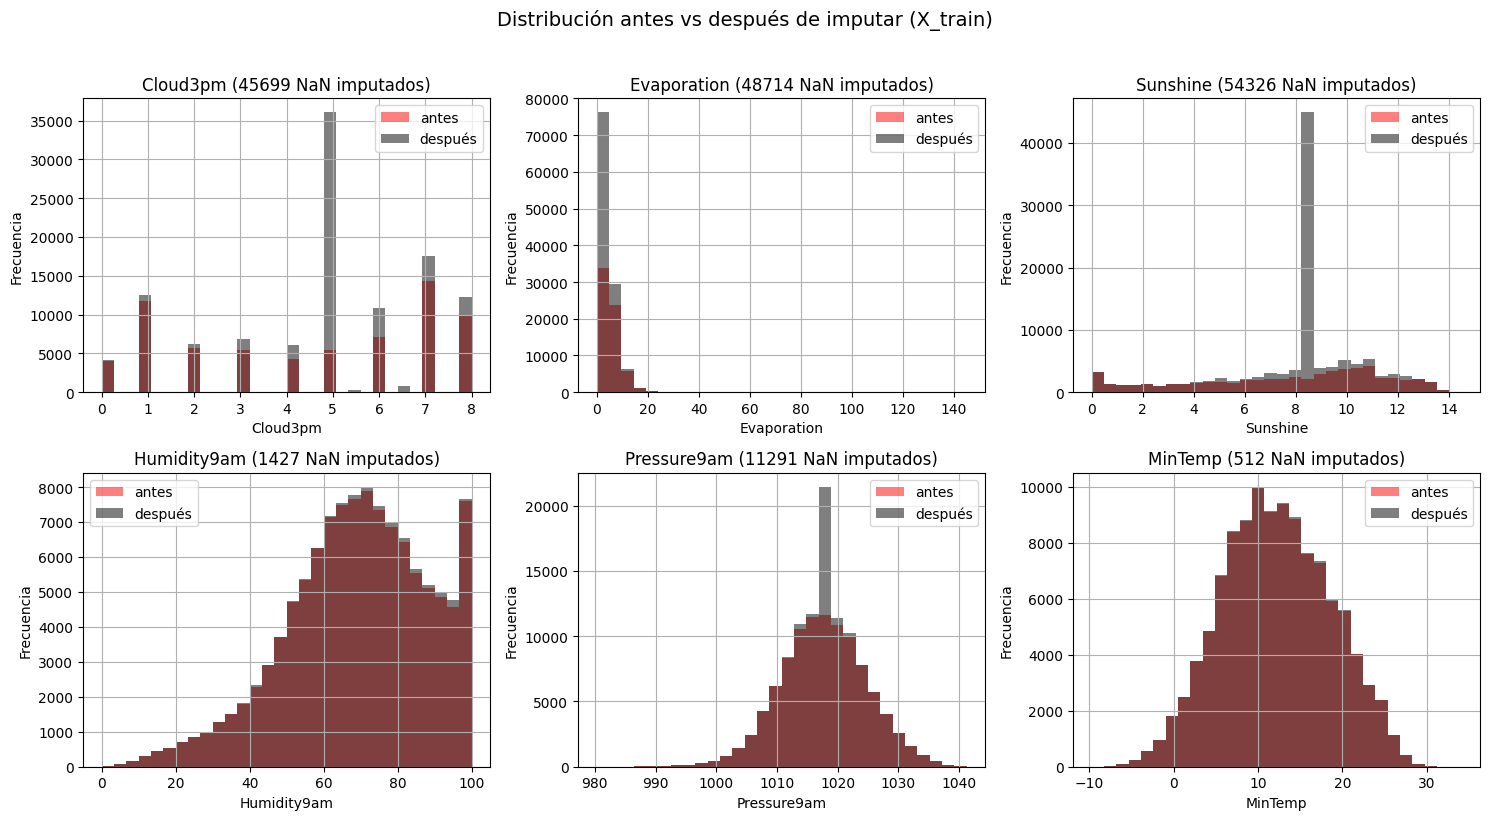

In [204]:
# QA visual: comparar distribuciones antes vs después de imputar (en X_train)
# Usamos las variables más afectadas por NaN para ver si la imputación las distorsionó

vars_num = ['Cloud3pm', 'Evaporation', 'Sunshine', 'Humidity9am', 'Pressure9am', 'MinTemp']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, c in enumerate(vars_num):
    ax = axes[i // 3, i % 3]
    X_train[c].dropna().hist(ax=ax, bins=30, alpha=0.5, color='red', label='antes')
    X1_train[c].hist(ax=ax, bins=30, alpha=0.5, color='black', label='después')
    ax.set_title(f'{c} ({X_train[c].isna().sum()} NaN imputados)')
    ax.set_xlabel(c)
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.suptitle('Distribución antes vs después de imputar (X_train)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

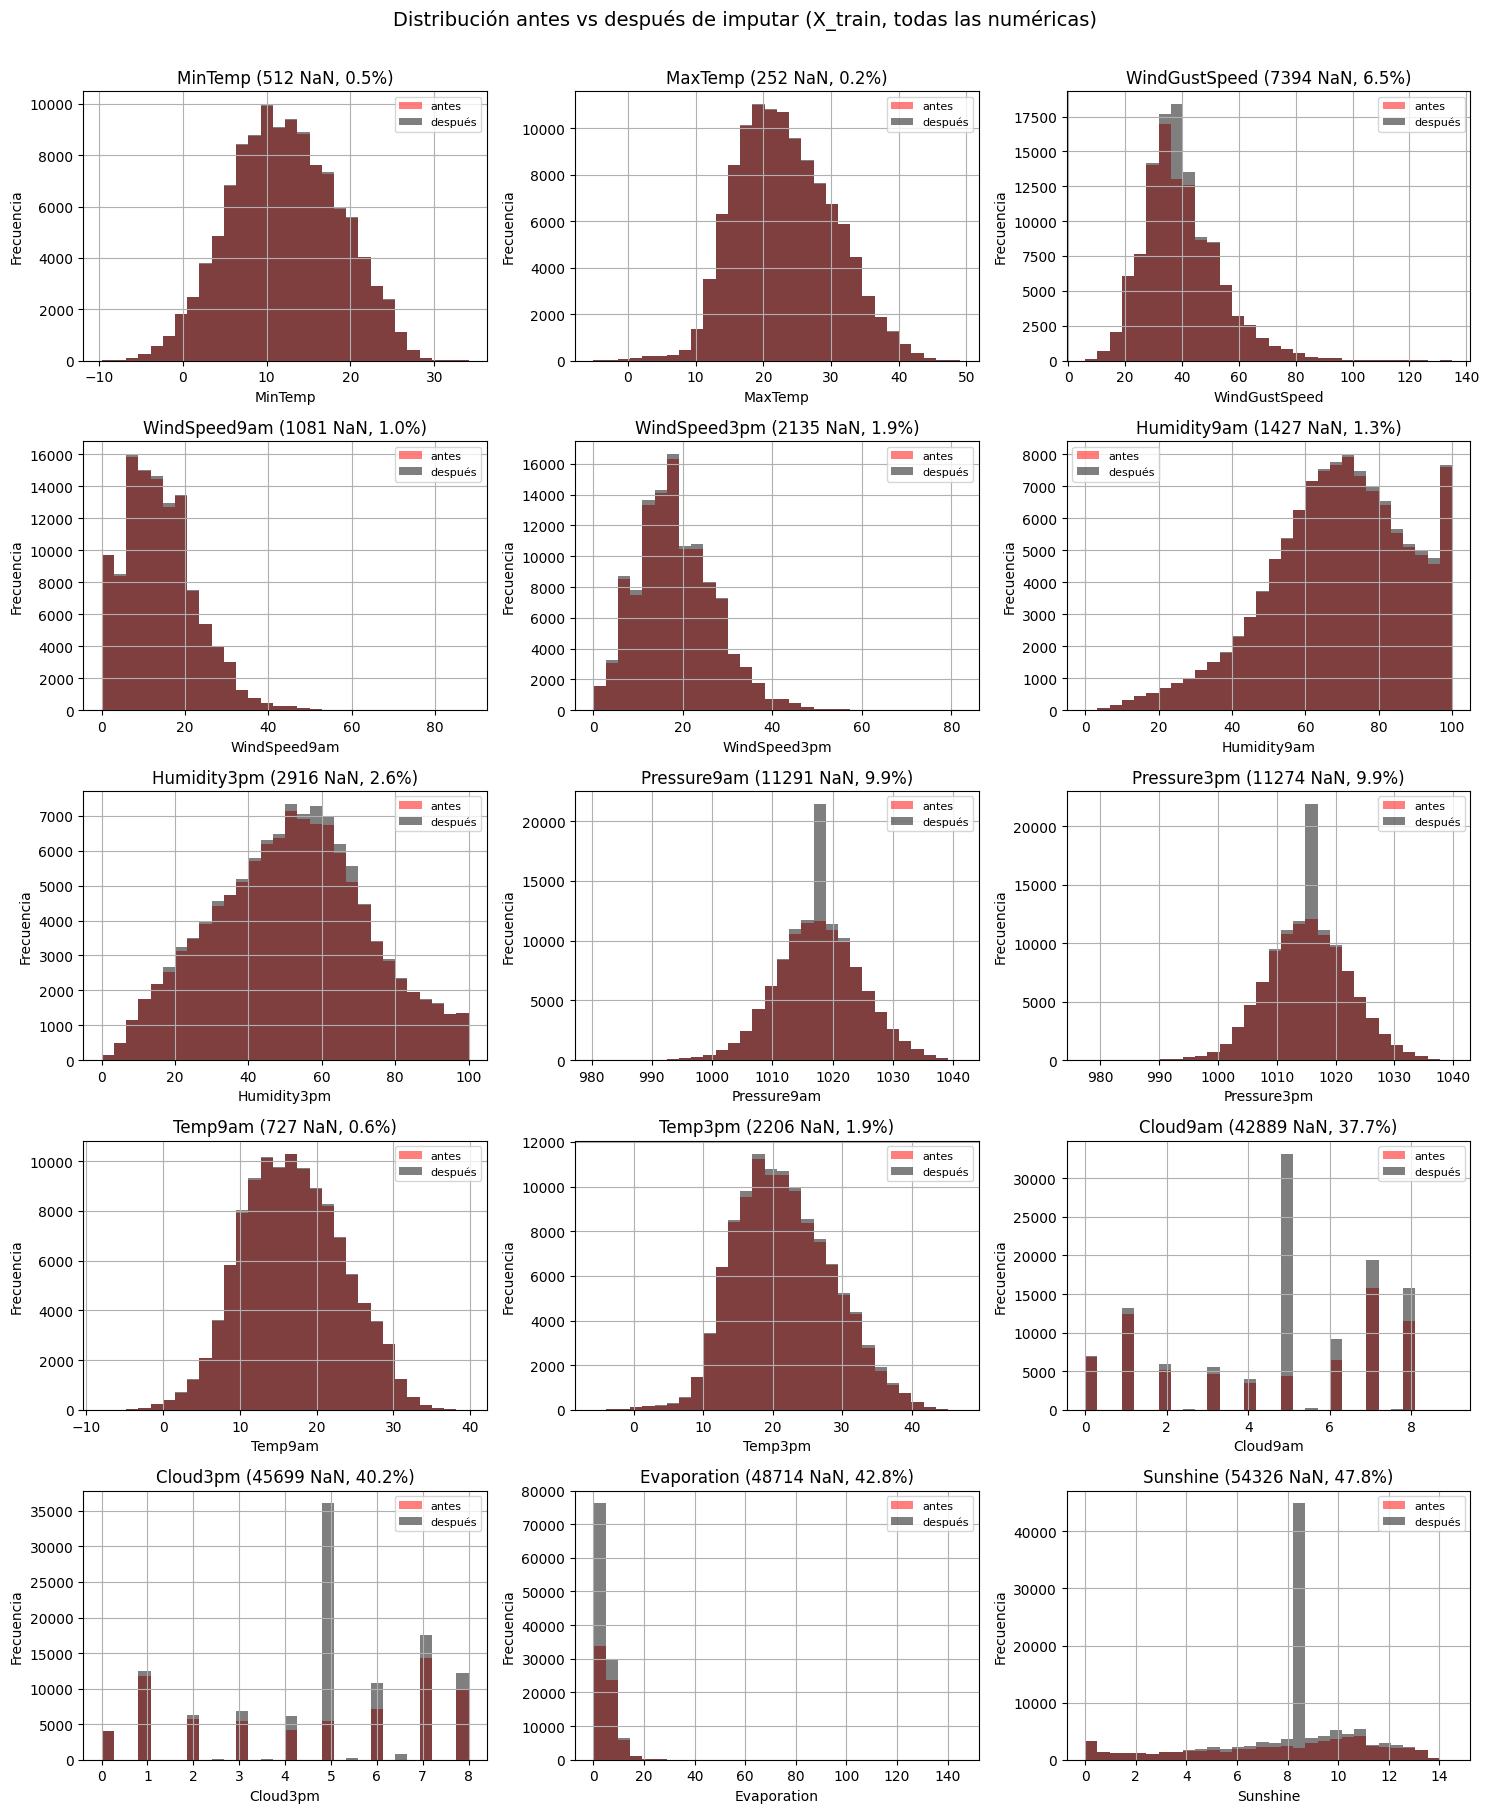

In [205]:
#comparar distribuciones antes vs después de imputar (X_train)
#para todas las variables numéricas que pasaron por la cascada

vars_num = ['MinTemp', 'MaxTemp', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
            'Temp9am', 'Temp3pm', 'Cloud9am', 'Cloud3pm', 'Evaporation', 'Sunshine']

fig, axes = plt.subplots(5, 3, figsize=(15, 18))

for i, c in enumerate(vars_num):
    ax = axes[i // 3, i % 3]
    X_train[c].dropna().hist(ax=ax, bins=30, alpha=0.5, color='red', label='antes')
    X1_train[c].hist(ax=ax, bins=30, alpha=0.5, color='black', label='después')
    n_imp = X_train[c].isna().sum()
    pct = round(100 * n_imp / len(X_train), 1)
    ax.set_title(f'{c} ({n_imp} NaN, {pct}%)')
    ax.set_xlabel(c)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución antes vs después de imputar (X_train, todas las numéricas)',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


podemos ver el antes y el despues de las imputaciones. 
 * las variables con bajo % de NaN las distribuciones se mantienen practicamente iguales
 * Para 'Sunshine' y 'Evaporation' con >40% de NaN, se nota claramente la concentracion en la mediana.
Por esto es que evaluamos clima2 como alternativa sin esas variables

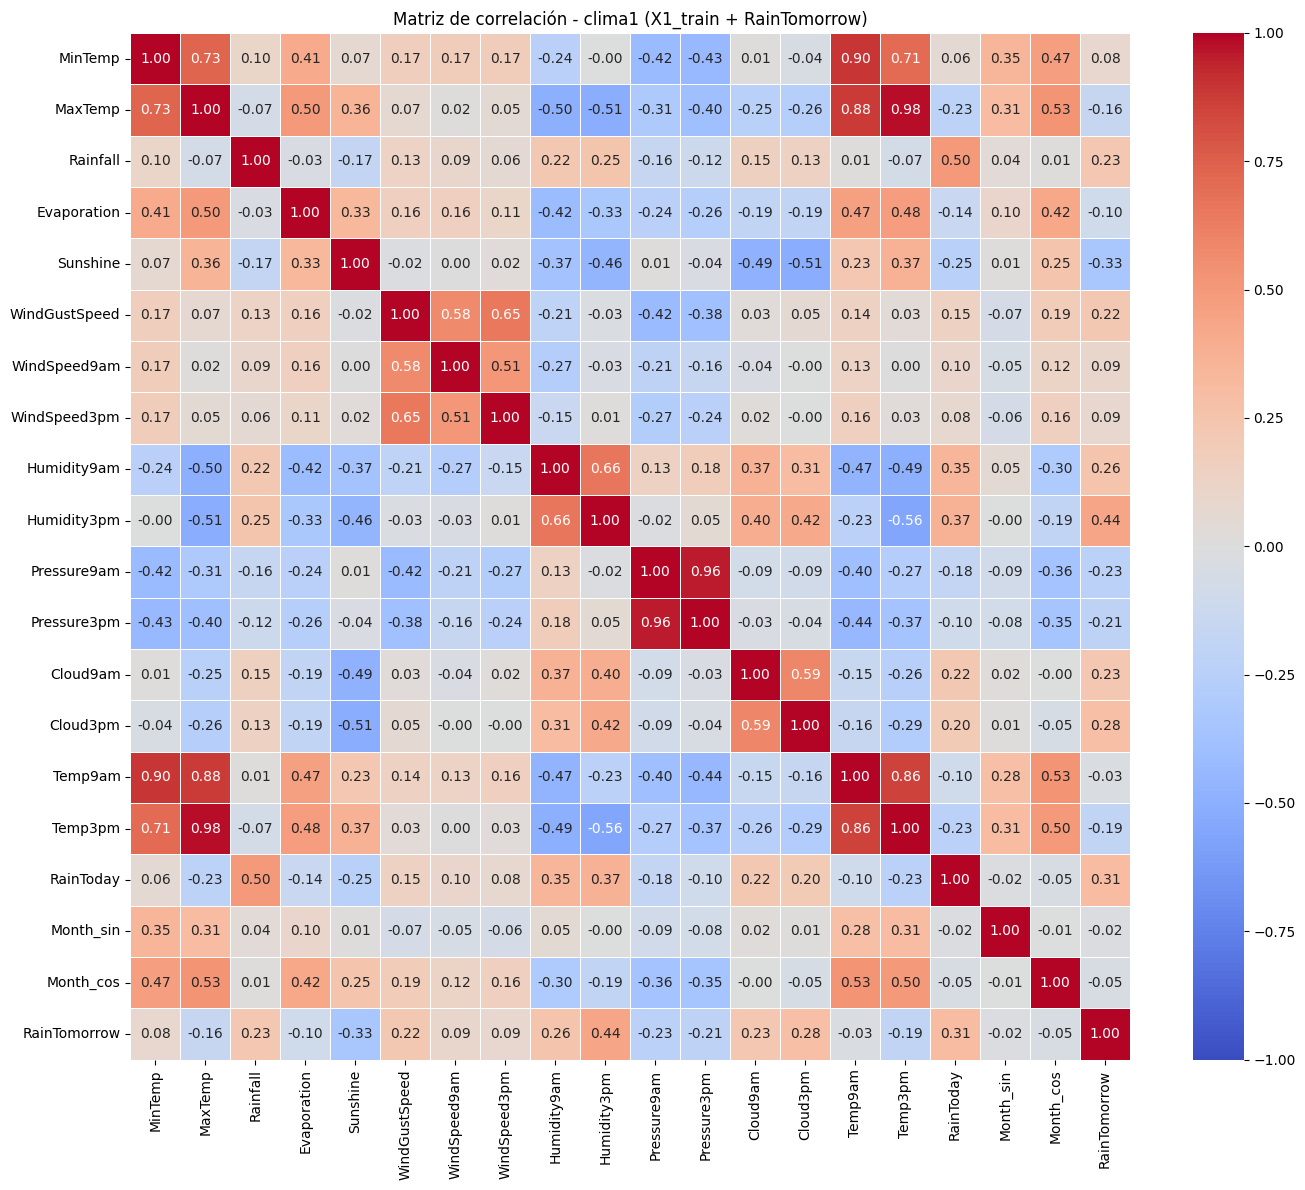

In [210]:
# Matriz de correlación sobre clima1 + target, sin flags ni one-hot
# El target (y_train) se suma al frame para ver correlaciones con RainTomorrow

cols_corr = [c for c in X1_train.columns
             if not c.endswith('_missing')
             and not c.startswith('WindGustDir_')
             and not c.startswith('WindDir9am_')
             and not c.startswith('WindDir3pm_')]

# Concatenamos las features filtradas con el target
data_corr = pd.concat([X1_train[cols_corr], y_train], axis=1)

corr1 = data_corr.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr1, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5,
            center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlación - clima1 (X1_train + RainTomorrow)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Escalado

In [206]:
from sklearn.preprocessing import StandardScaler

#identificamos columnas con variables continuas (excluyendo binarias 0/1)
def cols_continuas(df):
    return [c for c in df.columns if not set(df[c].unique()).issubset({0, 1})]

#  clima1
cols_c1 = cols_continuas(X1_train)
scaler1 = StandardScaler()
X1_train[cols_c1] = scaler1.fit_transform(X1_train[cols_c1])
X1_test[cols_c1]  = scaler1.transform(X1_test[cols_c1])

# clima2
cols_c2 = cols_continuas(X2_train)
scaler2 = StandardScaler()
X2_train[cols_c2] = scaler2.fit_transform(X2_train[cols_c2])
X2_test[cols_c2]  = scaler2.transform(X2_test[cols_c2])

#Verificacion
print(f'clima1 train \nmedia ≈ 0:', X1_train[cols_c1].mean().abs().mean().round(4),
      '| std ≈ 1:', X1_train[cols_c1].std().mean().round(4))
print(f'clima2 train \nmedia ≈ 0:', X2_train[cols_c2].mean().abs().mean().round(4),
      '| std ≈ 1:', X2_train[cols_c2].std().mean().round(4))


clima1 train 
media ≈ 0: 0.0 | std ≈ 1: 1.0
clima2 train 
media ≈ 0: 0.0 | std ≈ 1: 1.0


# 2 — Regresión Logística

Entrenamos cuatro modelos cruzando dos ejes:
- **Dataset**: clima1 (con Evap/Sun + flags) vs clima2 (sin Evap/Sun)
- **Pesos de clase**: baseline (default) vs `class_weight='balanced'` para mitigar el desbalance 77/22


In [ ]:
from sklearn.linear_model import LogisticRegression

# 4 modelos: (clima1, clima2) × (baseline, balanced)
lr_c1_base = LogisticRegression(random_state=42, max_iter=1000)
lr_c1_bal  = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_c2_base = LogisticRegression(random_state=42, max_iter=1000)
lr_c2_bal  = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Entrenar cada uno sobre su respectivo train
lr_c1_base.fit(X1_train, y_train)
lr_c1_bal.fit(X1_train,  y_train)
lr_c2_base.fit(X2_train, y_train)
lr_c2_bal.fit(X2_train,  y_train)


Modelos entrenados correctamente.


In [ ]:
print('clima1 baseline | nº de coeficientes:', len(lr_c1_base.coef_[0]))
print('clima2 baseline | nº de coeficientes:', len(lr_c2_base.coef_[0]))

clima1 baseline | nº de coeficientes: 77
clima2 baseline | nº de coeficientes: 73


"Entrenamos cuatro modelos: dos por dataset (clima1/clima2) y dos por peso de clase (default/balanced). El class_weight='balanced' reescalas los pesos según n_samples / (n_classes * n_samples_clase), lo que penaliza más fuerte los errores en la clase Yes (22% del dataset). En el siguiente paso comparamos las métricas para decidir qué combinación funciona mejor."

In [213]:
# Predicciones sobre test para cada modelo
y_pred_c1_base = lr_c1_base.predict(X1_test)
y_pred_c1_bal  = lr_c1_bal.predict(X1_test)
y_pred_c2_base = lr_c2_base.predict(X2_test)
y_pred_c2_bal  = lr_c2_bal.predict(X2_test)

elegimos como metrica adicional MCC. Esto nos permite ver que tan correlacionadas estan las predicciones del modelo con las etiquetas reales, ademas es una metrica robusta contra el desbalance.

In [214]:
#funcon auxiliar
def metricas(y_true, y_pred, nombre):
    return {
        'modelo': nombre,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_yes': precision_score(y_true, y_pred, pos_label=1),
        'recall_yes': recall_score(y_true, y_pred, pos_label=1),
        'f1_yes': f1_score(y_true, y_pred, pos_label=1),
        'mcc': matthews_corrcoef(y_true, y_pred),
    }

resumen = pd.DataFrame([
    metricas(y_test, y_pred_c1_base, 'lr_c1_base'),
    metricas(y_test, y_pred_c1_bal,  'lr_c1_bal'),
    metricas(y_test, y_pred_c2_base, 'lr_c2_base'),
    metricas(y_test, y_pred_c2_bal,  'lr_c2_bal'),
])

resumen.round(4)


,modelo,accuracy,precision_yes,recall_yes,f1_yes,mcc
0,lr_c1_base,0.8428,0.7133,0.4997,0.5877,0.5062
1,lr_c1_bal,0.7882,0.5187,0.7689,0.6195,0.4982
2,lr_c2_base,0.8421,0.7140,0.4936,0.5837,0.5030
3,lr_c2_bal,0.7845,0.5129,0.7681,0.6151,0.4922


metricas:
accuracy: aciertos totales / total
precision_yes: De los que predijo Yes, cuantos fueron Yes realmente
recall_yes: de los Yes reales, cuantos detecto
f1_yes: media armonica de precision_yes y recall_yes
mcc: correlacion de Pearson entre prediccion y target. es robusta al desbalance, metrica global que considera los 4 cuadrantes. Muestra la calidad general de prediccion y como para los 4 modelos se mantiene con valores cercanos a 0.5 la calidad general de prediccion es parecida, lo que cambia es donde acepta equivocarse el modelo(FN vs FP)

In [ ]:
#queremos confirmar que balanceando no solo se mejora recall en Yes, sino que tambien podemos ver que pasa con No
modelos = [
    ('lr_c1_base', lr_c1_base, X1_test),
    ('lr_c1_bal',  lr_c1_bal,  X1_test),
    ('lr_c2_base', lr_c2_base, X2_test),
    ('lr_c2_bal',  lr_c2_bal,  X2_test),
]

for nombre, modelo, X_test_local in modelos:
    print(nombre)
    print(classification_report(y_test, modelo.predict(X_test_local), target_names=['No', 'Yes']))

lr_c1_base
              precision    recall  f1-score   support

          No       0.87      0.94      0.90     22057
         Yes       0.71      0.50      0.59      6374

    accuracy                           0.84     28431
   macro avg       0.79      0.72      0.75     28431
weighted avg       0.83      0.84      0.83     28431

lr_c1_bal
              precision    recall  f1-score   support

          No       0.92      0.79      0.85     22057
         Yes       0.52      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431

lr_c2_base
              precision    recall  f1-score   support

          No       0.87      0.94      0.90     22057
         Yes       0.71      0.49      0.58      6374

    accuracy                           0.84     28431
   macro avg       0.79      0.72      0.74     28431
weighted avg       0.83      0.84      0.8

Elegimos MCC porque está diseñado para clasificación binaria desbalanceada, que es nuestro caso (77/22). A diferencia de accuracy, MCC no se deja llevar por una clase dominante: un modelo que siempre predice 'No' saca accuracy de 77% pero MCC de 0 y esto es exactamente a lo que queremos estar cubiertos

**Conclusion sobre los modelos:**

* La accuracy nos engaña por el desbalance del 77/22. Si siempre predecimos "No" sacamos 77% sin haber aprendido nada del modelo. Por eso priorizamos recall_yes (cuantos dias de lluvia detectamos) y f1_yes (balance entre recall y precision sobre la clase positiva).

* Comparando clima1 con clima2 las metricas son casi iguales. Esto significa que Evaporation y Sunshine no aportan informacion util al modelo, ya que tenian >40% de NaN imputados. clima2 nos queda como la version mas aceptabñe porque tiene menos columnas y el mismo desempeño.

* Los modelos con class_weight='balanced' cambian precision por recall. Pasan de detectar el 50% de los dias lluviosos a 77%, pero la precision_yes baja de 0.71 a 0.52. El f1_yes mejora levemente (0.58 → 0.62).

* El MCC se mantiene cerca de 0.50 en los 4 modelos, es una correlación moderada-positiva entre predicción y target. Esto sugiere que la calidad general es parecida, lo que cambia es donde acepta equivocarse el modelo: el baseline prefiere no dar falsas alarmas, el balanced prefiere detectar mas lluvias aunque sume FP.

* Para elegir cual modelo conviene hay que pensar el costo de cada error. Un FN (no detectar lluvia y salir sin paraguas) suele ser mas costoso que un FP (llevar paraguas innecesariamente). Por esto preferimos los _bal. Lo confirmamos con la matriz de confusion.


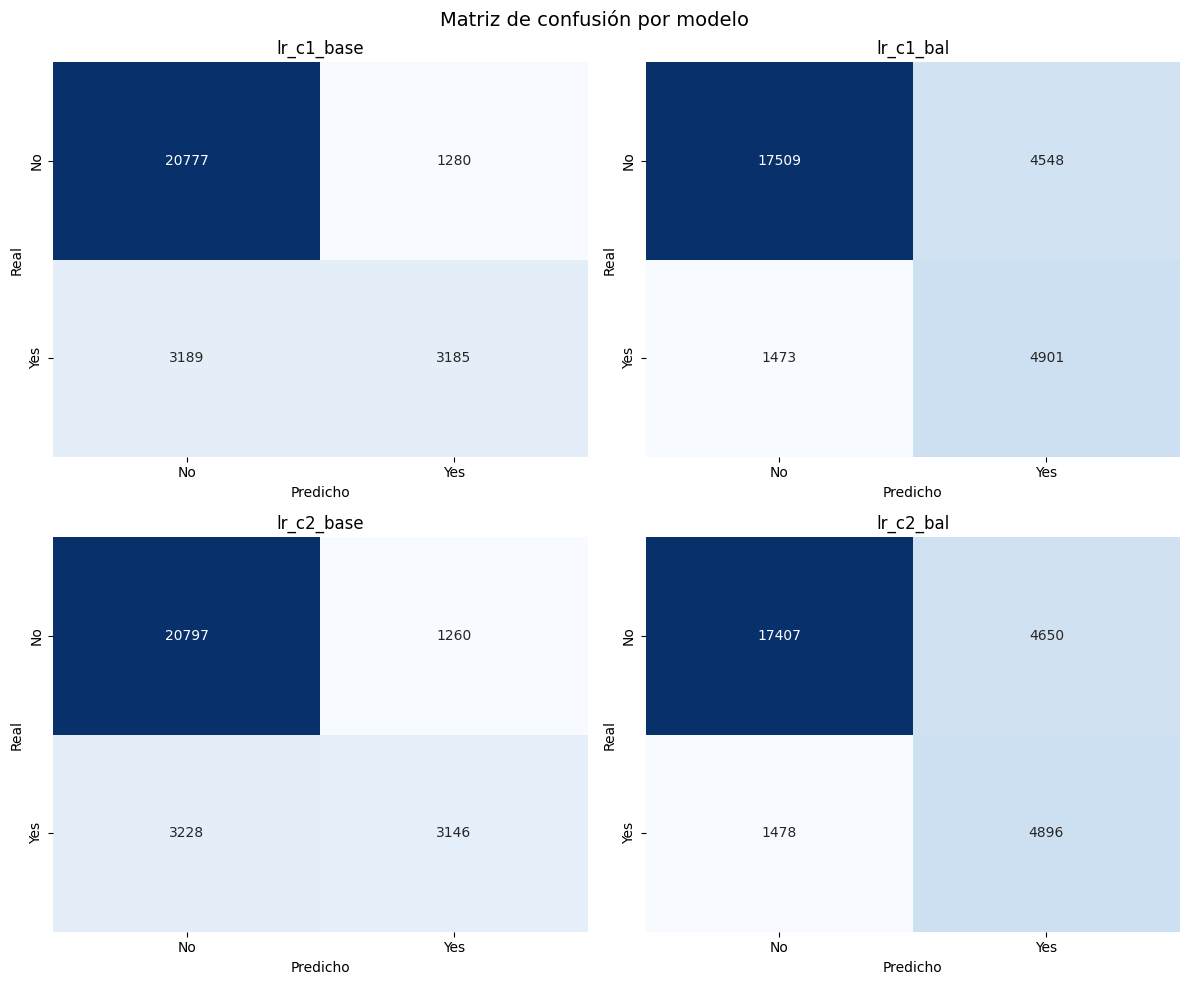

In [219]:
modelos_conf = [
    ('lr_c1_base', y_pred_c1_base),
    ('lr_c1_bal',  y_pred_c1_bal),
    ('lr_c2_base', y_pred_c2_base),
    ('lr_c2_bal',  y_pred_c2_bal),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (nombre, y_pred) in enumerate(modelos_conf):
    ax = axes[i // 2, i % 2]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                ax=ax, cbar=False)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(nombre)

plt.suptitle('Matriz de confusión por modelo', fontsize=14)
plt.tight_layout()
plt.show()
